In [ ]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install --upgrade pip setuptools wheel
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn keras xgboost

Looking in links: /tmp/tmpg86m2noo
Processing /tmp/tmpg86m2noo/pip-25.0.1-py3-none-any.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 155.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 162.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 103.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 72.9 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 88.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 107.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 91.4 MB/s  0:00:0

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

In [2]:
ax_t1 = pd.read_csv("ax_t1_radiomics_train.csv")
ax_t1c = pd.read_csv("ax_t1c_radiomics_train.csv")
ax_t2 = pd.read_csv("ax_t2_radiomics_train.csv")
ax_t2f = pd.read_csv("ax_t2f_radiomics_train.csv")
    

In [3]:
# Rename radiomics columns to include modality as prefix
dfs = [ax_t1, ax_t1c, ax_t2, ax_t2f]
modality_names = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

dfs_renamed = []
for df, modality in zip(dfs, modality_names):
    df_copy = df.drop(columns=['sex', 'age', 'modality']).copy()
    # Rename all radiomics columns to have modality prefix
    radiomics_cols = [col for col in df_copy.columns if col != 'case_id']
    new_names = {col: f'{modality}_{col}' for col in radiomics_cols}
    df_copy = df_copy.rename(columns=new_names)
    dfs_renamed.append(df_copy)

# Merge all on case_id
final_df = dfs_renamed[0]
for df in dfs_renamed[1:]:
    final_df = pd.merge(final_df, df, on='case_id')

final_df

,case_id,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,ax_t1c_rad_firstorder_Mean,ax_t1c_rad_firstorder_Entropy,ax_t1c_rad_firstorder_90Percentile,ax_t1c_rad_glcm_Contrast,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,7,0.372618,0.711361,0.806647,0.022080,0.855639,0.307252,0.529564,0.576312,0.018428,...,1.155277,6.772929e-02,2.346767,0.007287,1.111242e-01,0.474135,0.086630,0.665828,0.003289,0.100646
1,2146,0.487399,0.490950,0.941266,0.011772,0.576980,0.782262,0.306574,1.474236,0.007273,...,0.980814,1.475006e-01,1.704906,0.005478,1.866804e-01,NaN,NaN,NaN,NaN,NaN
2,2379,0.592563,0.577867,0.972408,0.064197,0.871453,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2113,1.395996,0.002940,1.822959,0.000174,0.003602,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2526,0.476454,0.221468,0.681786,0.009627,0.285528,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,1692,0.493102,0.446089,0.852497,0.019587,0.568339,0.834903,0.288749,1.256402,0.009568,...,0.343381,6.356453e-01,0.963037,0.064665,9.542412e-01,NaN,NaN,NaN,NaN,NaN
1979,2932,0.353850,0.350198,0.560908,0.016661,0.455032,0.364656,0.079200,0.520431,0.003687,...,0.153034,7.822304e-01,0.448524,0.060984,1.096093e+00,0.157154,0.640751,0.443251,0.042109,0.875832
1980,1706,0.672680,0.292004,0.991626,0.017320,0.375776,0.784760,0.146311,0.948136,0.009814,...,0.790702,4.642697e-02,1.962711,0.003008,6.737622e-02,0.606900,0.277542,0.895277,0.014441,0.362646
1981,1984,0.767376,0.124926,1.023174,0.006336,0.167074,1.331244,0.001595,1.522405,0.000110,...,0.661422,-3.200000e-16,1.141988,0.000000,-3.200000e-16,NaN,NaN,NaN,NaN,NaN


In [21]:
clinical_total = pd.read_csv("train_patient_info.csv")
clinical_total

,case_id,Sex,Age,Tumor Location,Signal Intensity (T1),Signal Intensity (T1c),Signal Intensity (T2),Signal Intensity (T2-FLAIR)
0,7,female,51.0,Right frontal region,isointense,heterogeneous,isointense,heterogeneous
1,2146,unknown,NaN,Right cerebellum,isointense,homogeneous,hyperintense,hyperintense
2,2379,unknown,NaN,Right cranial fossa,isointense,homogeneous,isointense,hyperintense
3,2113,unknown,NaN,Right cerebellopontine angle,hypointense,homogeneous,hyperintense,hyperintense
4,2526,unknown,NaN,Left Frontal Lobe,hypointense,hyperintense,hyperintense,hyperintense
...,...,...,...,...,...,...,...,...
1978,1692,unknown,NaN,Left pontocerebellar angle and fourth ventricle,isointense,heterogeneous,isointense,isointense
1979,2932,female,56.0,Pineal region,hypointense,unknown,isointense,heterogeneous
1980,1706,female,33.0,Medulla oblongata - below the fourth ventricle,isointense,unknown,hyperintense,hyperintense
1981,1984,female,38.0,"Pineal region, brainstem, third and fourth ven...",hypointense,heterogeneous,isointense,isointense


### Note to self:
#### Clinical information has radiomics data as QUALITATIVE variables
#### Radiomic information has radiomic data as QUANTITATIVE variables, but more missing data (e.g artifact loss)

In [5]:
clinical = clinical_total[["case_id", "Sex", "Age"]]
clinical

,case_id,Sex,Age
0,7,female,51.0
1,2146,unknown,NaN
2,2379,unknown,NaN
3,2113,unknown,NaN
4,2526,unknown,NaN
...,...,...,...
1978,1692,unknown,NaN
1979,2932,female,56.0
1980,1706,female,33.0
1981,1984,female,38.0


### Skewed data, use median

In [23]:
ages = clinical.Age.fillna(clinical.Age.median())
ages

0       51.0
1       51.0
2       51.0
3       51.0
4       51.0
        ... 
1978    51.0
1979    56.0
1980    33.0
1981    38.0
1982    25.0
Name: Age, Length: 1983, dtype: float64

In [24]:
clinical

,case_id,Sex,Age
0,7,female,51.0
1,2146,unknown,NaN
2,2379,unknown,NaN
3,2113,unknown,NaN
4,2526,unknown,NaN
...,...,...,...
1978,1692,unknown,NaN
1979,2932,female,56.0
1980,1706,female,33.0
1981,1984,female,38.0


(array([ 21.,  24.,  13.,  32.,  59.,  77., 139., 120.,  69.,  45.]),
 array([ 3. , 10.3, 17.6, 24.9, 32.2, 39.5, 46.8, 54.1, 61.4, 68.7, 76. ]),
 <BarContainer object of 10 artists>)

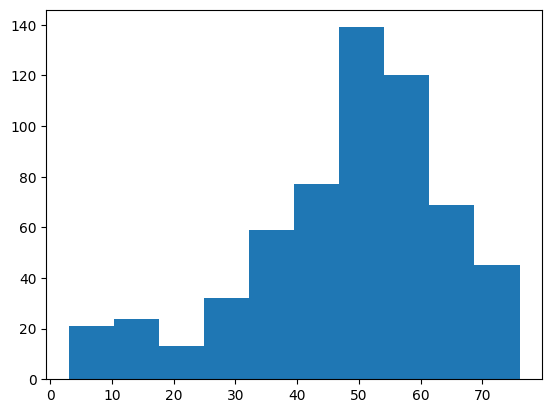

In [25]:
import matplotlib.pyplot as plt
age2 = clinical.Age
age2.dropna()
plt.hist(age2)

In [26]:
clinical_encoded = pd.get_dummies(data=clinical, columns=["Sex"])
clinical_encoded

,case_id,Age,Sex_female,Sex_male,Sex_unknown
0,7,51.0,True,False,False
1,2146,NaN,False,False,True
2,2379,NaN,False,False,True
3,2113,NaN,False,False,True
4,2526,NaN,False,False,True
...,...,...,...,...,...
1978,1692,NaN,False,False,True
1979,2932,56.0,True,False,False
1980,1706,33.0,True,False,False
1981,1984,38.0,True,False,False


In [27]:
clinical_encoded = pd.get_dummies(data=clinical, columns=["Sex"])
clinical_encoded

,case_id,Age,Sex_female,Sex_male,Sex_unknown
0,7,51.0,True,False,False
1,2146,NaN,False,False,True
2,2379,NaN,False,False,True
3,2113,NaN,False,False,True
4,2526,NaN,False,False,True
...,...,...,...,...,...
1978,1692,NaN,False,False,True
1979,2932,56.0,True,False,False
1980,1706,33.0,True,False,False
1981,1984,38.0,True,False,False


### Train features

In [28]:
final_features = pd.merge(clinical_encoded, final_df, on="case_id")

In [29]:
final_features

,case_id,Age,Sex_female,Sex_male,Sex_unknown,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,7,51.0,True,False,False,0.372618,0.711361,0.806647,0.022080,0.855639,...,1.155277,6.772929e-02,2.346767,0.007287,1.111242e-01,0.474135,0.086630,0.665828,0.003289,0.100646
1,2146,NaN,False,False,True,0.487399,0.490950,0.941266,0.011772,0.576980,...,0.980814,1.475006e-01,1.704906,0.005478,1.866804e-01,NaN,NaN,NaN,NaN,NaN
2,2379,NaN,False,False,True,0.592563,0.577867,0.972408,0.064197,0.871453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2113,NaN,False,False,True,1.395996,0.002940,1.822959,0.000174,0.003602,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2526,NaN,False,False,True,0.476454,0.221468,0.681786,0.009627,0.285528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,1692,NaN,False,False,True,0.493102,0.446089,0.852497,0.019587,0.568339,...,0.343381,6.356453e-01,0.963037,0.064665,9.542412e-01,NaN,NaN,NaN,NaN,NaN
1979,2932,56.0,True,False,False,0.353850,0.350198,0.560908,0.016661,0.455032,...,0.153034,7.822304e-01,0.448524,0.060984,1.096093e+00,0.157154,0.640751,0.443251,0.042109,0.875832
1980,1706,33.0,True,False,False,0.672680,0.292004,0.991626,0.017320,0.375776,...,0.790702,4.642697e-02,1.962711,0.003008,6.737622e-02,0.606900,0.277542,0.895277,0.014441,0.362646
1981,1984,38.0,True,False,False,0.767376,0.124926,1.023174,0.006336,0.167074,...,0.661422,-3.200000e-16,1.141988,0.000000,-3.200000e-16,NaN,NaN,NaN,NaN,NaN


### Train class

In [30]:
train = pd.read_json("train.json")
train_class = train.T.Overall_class
train_class = pd.DataFrame(train_class, columns=['Overall_class'])
train_class

,Overall_class
7,Meningioma
2146,Meningioma
2379,Meningioma
2113,Meningioma
2526,Meningioma
...,...
1692,Pineal tumour and Choroid plexus tumour
2932,Pineal tumour and Choroid plexus tumour
1706,Pineal tumour and Choroid plexus tumour
1984,Pineal tumour and Choroid plexus tumour


### Validation set

In [31]:
valid = pd.read_json("val.json")
valid_class = valid.T.Overall_class
valid_class = pd.DataFrame(valid_class, columns=['Overall_class'])
valid_class

,Overall_class
153,Meningioma
2555,Meningioma
2393,Meningioma
2086,Meningioma
2508,Meningioma
...,...
2043,Tumors of the sellar region
2020,Tumors of the sellar region
2931,Pineal tumour and Choroid plexus tumour
2853,Pineal tumour and Choroid plexus tumour


In [49]:
ax_t1 = pd.read_csv("ax_t1_radiomics_val.csv")
ax_t1c = pd.read_csv("ax_t1c_radiomics_val.csv")
ax_t2 = pd.read_csv("ax_t2_radiomics_val.csv")
ax_t2f = pd.read_csv("ax_t2f_radiomics_val.csv")

dfs_val = [ax_t1, ax_t1c, ax_t2, ax_t2f]
modality_names = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

dfs_val_renamed = []
for df_val, modality in zip(dfs_val, modality_names):  # Fixed: dfs2 -> dfs_val
    df_val_copy = df_val.drop(columns=['sex', 'age', 'modality']).copy()
    # Rename all radiomics columns to have modality prefix
    radiomics_cols = [col for col in df_val_copy.columns if col != 'case_id']
    new_names = {col: f'{modality}_{col}' for col in radiomics_cols}
    df_val_copy = df_val_copy.rename(columns=new_names)
    dfs_val_renamed.append(df_val_copy)  # Fixed: df2_val -> df_val_copy

# Merge all on case_id
final_df_val = dfs_val_renamed[0]
for df in dfs_val_renamed[1:]:
    final_df_val = pd.merge(final_df_val, df, on='case_id')

final_df_val 

,case_id,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,ax_t1c_rad_firstorder_Mean,ax_t1c_rad_firstorder_Entropy,ax_t1c_rad_firstorder_90Percentile,ax_t1c_rad_glcm_Contrast,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,153,0.609980,0.600373,1.771189,0.077879,0.928446,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2555,1.077522,0.049439,1.563126,0.002673,0.069169,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2393,0.194824,0.527725,0.432289,0.033250,0.716927,0.367053,0.058407,1.077771,0.003346,...,0.073533,9.911575e-01,0.357325,0.083610,1.404392e+00,0.281906,2.424578e-01,0.643367,0.017458,3.373622e-01
3,2086,0.479061,0.433142,0.678044,0.011476,0.517023,0.466351,0.489874,0.809012,0.018508,...,1.217079,-3.200000e-16,2.532621,0.000000,-3.200000e-16,0.621725,5.092699e-01,1.337433,0.017311,6.288204e-01
4,2508,0.332762,0.580652,0.610391,0.022549,0.722804,0.216556,0.694297,0.472942,0.024551,...,0.466680,9.100715e-01,1.816654,0.060432,1.233008e+00,0.424255,4.836868e-01,1.142390,0.033561,6.715944e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,2043,0.460886,0.528230,0.806795,0.028810,0.696275,NaN,NaN,NaN,NaN,...,0.477956,6.589952e-02,1.142419,0.010455,1.205573e-01,0.539098,2.483483e-01,0.743099,0.017100,3.459824e-01
279,2020,-0.060977,0.999980,0.426424,0.041129,1.247142,0.282634,0.917144,1.002444,0.036668,...,0.967748,6.574531e-02,2.652233,0.003109,8.796717e-02,0.419150,4.464813e-01,0.749567,0.016242,5.433540e-01
280,2931,1.162956,0.093444,1.859389,0.004791,0.127337,1.023371,0.053720,1.610730,0.002767,...,1.288397,9.961768e-02,1.877620,0.005267,1.360087e-01,1.308309,1.017328e-01,1.972046,0.005566,1.396847e-01
281,2853,1.138883,0.013216,1.510577,0.001236,0.021323,0.855130,0.318539,1.226774,0.012063,...,0.932545,2.116923e-01,1.800298,0.010901,2.819784e-01,1.049820,3.344020e-01,1.623627,0.013190,4.235797e-01


In [53]:
clinical_test_total = pd.read_csv("val_patient_info.csv")
clinical_test_total

,case_id,Sex,Age,Tumor Location,Signal Intensity (T1),Signal Intensity (T1c),Signal Intensity (T2),Signal Intensity (T2-FLAIR)
0,153,unknown,NaN,Right Temporal Lobe,hypointense,hyperintense,hyperintense,hyperintense
1,2555,unknown,NaN,Left parieto-occipital junction,isointense,heterogeneous,hyperintense,hyperintense
2,2393,unknown,NaN,Left frontal parasagittal,isointense,homogeneous,hyperintense,isointense
3,2086,unknown,NaN,"Left Temporal Lobe, Left Occipital Lobe",hypointense,hyperintense,hyperintense,hyperintense
4,2508,female,45.0,Left cranial fossa,isointense,hyperintense,isointense,hyperintense
...,...,...,...,...,...,...,...,...
278,2043,male,56.0,sellar region,isointense,hyperintense,isointense,hyperintense
279,2020,male,17.0,sellar and suprasellar regions,hypointense,unknown,hyperintense,hyperintense
280,2931,male,42.0,midbrain,isointense,unknown,hyperintense,hyperintense
281,2853,unknown,NaN,Right lateral ventricle trigone,hypointense,unknown,hyperintense,hyperintense


In [55]:
clinical_val = clinical_test_total[["case_id", "Sex", "Age"]]
clinical_val_encoded = pd.get_dummies(clinical_val, columns=['Sex'])
clinical_val_encoded

,case_id,Age,Sex_female,Sex_male,Sex_unknown
0,153,NaN,False,False,True
1,2555,NaN,False,False,True
2,2393,NaN,False,False,True
3,2086,NaN,False,False,True
4,2508,45.0,True,False,False
...,...,...,...,...,...
278,2043,56.0,False,True,False
279,2020,17.0,False,True,False
280,2931,42.0,False,True,False
281,2853,NaN,False,False,True


In [57]:
final_val_features = pd.merge(clinical_val_encoded, final_df_val, on="case_id")
final_val_features

,case_id,Age,Sex_female,Sex_male,Sex_unknown,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,153,NaN,False,False,True,0.609980,0.600373,1.771189,0.077879,0.928446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2555,NaN,False,False,True,1.077522,0.049439,1.563126,0.002673,0.069169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2393,NaN,False,False,True,0.194824,0.527725,0.432289,0.033250,0.716927,...,0.073533,9.911575e-01,0.357325,0.083610,1.404392e+00,0.281906,2.424578e-01,0.643367,0.017458,3.373622e-01
3,2086,NaN,False,False,True,0.479061,0.433142,0.678044,0.011476,0.517023,...,1.217079,-3.200000e-16,2.532621,0.000000,-3.200000e-16,0.621725,5.092699e-01,1.337433,0.017311,6.288204e-01
4,2508,45.0,True,False,False,0.332762,0.580652,0.610391,0.022549,0.722804,...,0.466680,9.100715e-01,1.816654,0.060432,1.233008e+00,0.424255,4.836868e-01,1.142390,0.033561,6.715944e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,2043,56.0,False,True,False,0.460886,0.528230,0.806795,0.028810,0.696275,...,0.477956,6.589952e-02,1.142419,0.010455,1.205573e-01,0.539098,2.483483e-01,0.743099,0.017100,3.459824e-01
279,2020,17.0,False,True,False,-0.060977,0.999980,0.426424,0.041129,1.247142,...,0.967748,6.574531e-02,2.652233,0.003109,8.796717e-02,0.419150,4.464813e-01,0.749567,0.016242,5.433540e-01
280,2931,42.0,False,True,False,1.162956,0.093444,1.859389,0.004791,0.127337,...,1.288397,9.961768e-02,1.877620,0.005267,1.360087e-01,1.308309,1.017328e-01,1.972046,0.005566,1.396847e-01
281,2853,NaN,False,False,True,1.138883,0.013216,1.510577,0.001236,0.021323,...,0.932545,2.116923e-01,1.800298,0.010901,2.819784e-01,1.049820,3.344020e-01,1.623627,0.013190,4.235797e-01


### Tune

In [65]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


le = LabelEncoder()
train_class_enc = le.fit_transform(train_class['Overall_class']) 
model = XGBClassifier(objective='multi:softprob', num_class=len(le.classes_), max_depth=4, learning_rate=0.3, n_estimators=100, use_label_encoder=False, random_state=42)
model.fit(final_features, train_class_enc)

y_pred = model.predict(final_val_features)
val_acc = accuracy_score(valid_class_enc, y_pred)
print(val_acc)

/home/ubuntu/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:22:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.9399293286219081


In [69]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

le = LabelEncoder()
train_class_enc = le.fit_transform(train_class['Overall_class'])
valid_class_enc = le.transform(valid_class['Overall_class'])

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.3, 0.5],
    'n_estimators': [50, 100, 150, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss'  
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,  
    scoring='accuracy',
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(final_features, train_class_enc)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(final_val_features)
val_acc = accuracy_score(valid_class_enc, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1.0}
Best cross-validation score: 0.9556
Validation Accuracy: 0.9364


### Test Features

In [33]:
ax_t1 = pd.read_csv("ax_t1_radiomics_test.csv")
ax_t1c = pd.read_csv("ax_t1c_radiomics_test.csv")
ax_t2 = pd.read_csv("ax_t2_radiomics_test.csv")
ax_t2f = pd.read_csv("ax_t2f_radiomics_test.csv")

dfs2 = [ax_t1, ax_t1c, ax_t2, ax_t2f]
modality_names = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

dfs2_renamed = []
for df2, modality in zip(dfs2, modality_names):
    df2_copy = df2.drop(columns=['sex', 'age', 'modality']).copy()
    # Rename all radiomics columns to have modality prefix
    radiomics_cols = [col for col in df2_copy.columns if col != 'case_id']
    new_names = {col: f'{modality}_{col}' for col in radiomics_cols}
    df2_copy = df2_copy.rename(columns=new_names)
    dfs2_renamed.append(df2_copy)

# Merge all on case_id
final_df2 = dfs2_renamed[0]
for df in dfs2_renamed[1:]:
    final_df2 = pd.merge(final_df2, df, on='case_id')

final_df2


,case_id,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,ax_t1c_rad_firstorder_Mean,ax_t1c_rad_firstorder_Entropy,ax_t1c_rad_firstorder_90Percentile,ax_t1c_rad_glcm_Contrast,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,1,0.180205,0.821929,0.638546,0.027905,0.999074,0.500343,0.521332,1.021734,0.023773,...,1.290208,4.661512e-01,2.397348,0.014115,5.655924e-01,0.355676,0.915165,1.198529,0.029558,1.109280
1,572,0.607346,0.644596,1.043989,0.065063,0.952653,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2139,0.634014,0.465362,0.956679,0.015133,0.557732,0.353744,0.636398,0.680625,0.019077,...,0.502027,5.592285e-01,2.054476,0.044550,7.966082e-01,0.412902,0.113301,0.642813,0.005551,0.144754
3,581,0.667168,0.317383,0.981924,0.014443,0.410936,0.431124,0.084425,0.543751,0.004809,...,1.011619,-3.200000e-16,1.556766,0.000000,-3.200000e-16,0.791488,0.045795,1.007620,0.002729,0.059841
4,175,0.739618,0.354090,1.354801,0.019489,0.470856,0.660372,0.084528,0.945942,0.005235,...,1.342956,1.399162e-02,2.023992,0.001200,2.254160e-02,1.131248,0.207167,1.514998,0.013040,0.286444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,2930,-0.465475,0.656368,0.241457,0.025204,0.800468,-0.387664,0.297593,-0.218051,0.015592,...,1.115007,8.303201e-01,2.242154,0.022739,9.797449e-01,NaN,NaN,NaN,NaN,NaN
568,2934,1.000530,0.123287,1.523959,0.006993,0.169729,1.180447,0.005651,1.368728,0.000347,...,0.966393,8.350180e-04,1.295681,0.000054,1.343714e-03,1.365124,0.004519,1.608438,0.000382,0.007564
569,1983,0.626844,0.144046,0.881093,0.009137,0.201903,0.441518,0.056512,0.536517,0.002358,...,0.503888,-3.200000e-16,0.715487,0.000000,-3.200000e-16,0.538165,0.046601,0.681473,0.002890,0.066415
570,1693,0.384427,0.635443,0.784518,0.022788,0.783662,0.309612,0.595267,0.616029,0.026041,...,0.597865,3.726949e-01,1.696485,0.023065,5.086243e-01,NaN,NaN,NaN,NaN,NaN


In [51]:
clinical_test_total = pd.read_csv("test_patient_info.csv")
clinical_test_total

,case_id,Sex,Age,Tumor Location,Signal Intensity (T1),Signal Intensity (T1c),Signal Intensity (T2),Signal Intensity (T2-FLAIR)
0,1,unknown,NaN,Left lateral ventricle,hypointense,hyperintense,hyperintense,heterogeneous
1,572,unknown,NaN,cranial fossa,hypointense,homogeneous,hyperintense,hyperintense
2,2139,unknown,NaN,Right pontocerebellar angle,hypointense,unknown,hyperintense,hyperintense
3,581,unknown,NaN,"Right Frontal Lobe, Right Parietal Lobe, Right...",hypointense,heterogeneous,hyperintense,hyperintense
4,175,unknown,NaN,"Right cerebellum, Right suprasellar region",isointense,homogeneous,isointense,hyperintense
...,...,...,...,...,...,...,...,...
567,2930,male,26.0,Pineal region,hypointense,unknown,hyperintense,hyperintense
568,2934,male,7.0,Pineal region,isointense,hyperintense,isointense,heterogeneous
569,1983,female,54.0,Pineal region,hypointense,heterogeneous,hyperintense,hyperintense
570,1693,unknown,NaN,Left lateral ventricle trigone,unknown,unknown,isointense,isointense


In [52]:
clinical_test = clinical_test_total[["case_id", "Sex", "Age"]]
clinical_test_encoded = pd.get_dummies(clinical_test, columns=['Sex'])
clinical_test_encoded

,case_id,Age,Sex_female,Sex_male,Sex_unknown
0,1,NaN,False,False,True
1,572,NaN,False,False,True
2,2139,NaN,False,False,True
3,581,NaN,False,False,True
4,175,NaN,False,False,True
...,...,...,...,...,...
567,2930,26.0,False,True,False
568,2934,7.0,False,True,False
569,1983,54.0,True,False,False
570,1693,NaN,False,False,True


In [35]:
final_test_features = pd.merge(clinical_test_encoded, final_df2, on="case_id")

In [36]:
final_test_features

,case_id,Age,Sex_female,Sex_male,Sex_unknown,ax_t1_rad_firstorder_Mean,ax_t1_rad_firstorder_Entropy,ax_t1_rad_firstorder_90Percentile,ax_t1_rad_glcm_Contrast,ax_t1_rad_glcm_JointEntropy,...,ax_t2_rad_firstorder_Mean,ax_t2_rad_firstorder_Entropy,ax_t2_rad_firstorder_90Percentile,ax_t2_rad_glcm_Contrast,ax_t2_rad_glcm_JointEntropy,ax_t2f_rad_firstorder_Mean,ax_t2f_rad_firstorder_Entropy,ax_t2f_rad_firstorder_90Percentile,ax_t2f_rad_glcm_Contrast,ax_t2f_rad_glcm_JointEntropy
0,1,NaN,False,False,True,0.180205,0.821929,0.638546,0.027905,0.999074,...,1.290208,4.661512e-01,2.397348,0.014115,5.655924e-01,0.355676,0.915165,1.198529,0.029558,1.109280
1,572,NaN,False,False,True,0.607346,0.644596,1.043989,0.065063,0.952653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2139,NaN,False,False,True,0.634014,0.465362,0.956679,0.015133,0.557732,...,0.502027,5.592285e-01,2.054476,0.044550,7.966082e-01,0.412902,0.113301,0.642813,0.005551,0.144754
3,581,NaN,False,False,True,0.667168,0.317383,0.981924,0.014443,0.410936,...,1.011619,-3.200000e-16,1.556766,0.000000,-3.200000e-16,0.791488,0.045795,1.007620,0.002729,0.059841
4,175,NaN,False,False,True,0.739618,0.354090,1.354801,0.019489,0.470856,...,1.342956,1.399162e-02,2.023992,0.001200,2.254160e-02,1.131248,0.207167,1.514998,0.013040,0.286444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,2930,26.0,False,True,False,-0.465475,0.656368,0.241457,0.025204,0.800468,...,1.115007,8.303201e-01,2.242154,0.022739,9.797449e-01,NaN,NaN,NaN,NaN,NaN
568,2934,7.0,False,True,False,1.000530,0.123287,1.523959,0.006993,0.169729,...,0.966393,8.350180e-04,1.295681,0.000054,1.343714e-03,1.365124,0.004519,1.608438,0.000382,0.007564
569,1983,54.0,True,False,False,0.626844,0.144046,0.881093,0.009137,0.201903,...,0.503888,-3.200000e-16,0.715487,0.000000,-3.200000e-16,0.538165,0.046601,0.681473,0.002890,0.066415
570,1693,NaN,False,False,True,0.384427,0.635443,0.784518,0.022788,0.783662,...,0.597865,3.726949e-01,1.696485,0.023065,5.086243e-01,NaN,NaN,NaN,NaN,NaN


In [37]:
# 0.967
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


le = LabelEncoder()
train_class_enc = le.fit_transform(train_class['Overall_class']) 
model = XGBClassifier(objective='multi:softprob', num_class=len(le.classes_), max_depth=4, learning_rate=0.3, n_estimators=100, use_label_encoder=False, random_state=42)
model.fit(final_features, train_class_enc)

y_pred = model.predict(final_test_features)


/home/ubuntu/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [12:59:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [71]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


le = LabelEncoder()
train_class_enc = le.fit_transform(train_class['Overall_class']) 
model = XGBClassifier(objective='multi:softprob', num_class=len(le.classes_), max_depth=6, learning_rate=0.1, n_estimators=200, colsample_bytree=1, min_child_weight=1, use_label_encoder=False, random_state=42)
model.fit(final_features, train_class_enc)

y_pred = model.predict(final_test_features)

/home/ubuntu/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:01:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [72]:
y_pred_labels = le.inverse_transform(y_pred)

In [73]:
y_pred_labels

array(['Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Meningioma',
       'Meningioma', 'Meningioma', 'Meningioma', 'Menin

In [74]:
case_id = final_test_features.case_id
case_id = pd.Series(case_id)
predictions = pd.Series(y_pred_labels)
merged = [case_id, predictions]
submission = pd.concat(merged, axis=1)
submission.columns = ['case_id', 'Overall_class']
submission.to_csv('submission.csv', index=False)

In [47]:
predictions = pd.Series(y_pred_labels)

0         1
1       572
2      2139
3       581
4       175
       ... 
567    2930
568    2934
569    1983
570    1693
571    1700
Name: case_id, Length: 572, dtype: int64